In [7]:
import mdtraj as md
import numpy as np

traj = md.load("/avogadro/joe/pure_tip4p_sim/300K/md.nc", top="/avogadro/joe/pure_tip4p_sim/300K/topol.prmtop", stride = 100)

In [8]:
ox = traj.topology.select("name O")

In [5]:
ox

array([    0,     4,     8, ..., 26432, 26436, 26440], shape=(6611,))

In [ ]:
pairs = traj.topology.select_pairs(ox, ox)

r, g = md.compute_rdf(traj, pairs, r_range=(0.2, 0.8), bin_width=0.002)  #nm
r_peak = r[np.argmax(g)] * 10  #A
print(f"First O-O peak at {r_peak:.3f} Å, g(r) = {g.max():.2f}")

First O-O peak at 2.770 Å, g(r) = 3.23


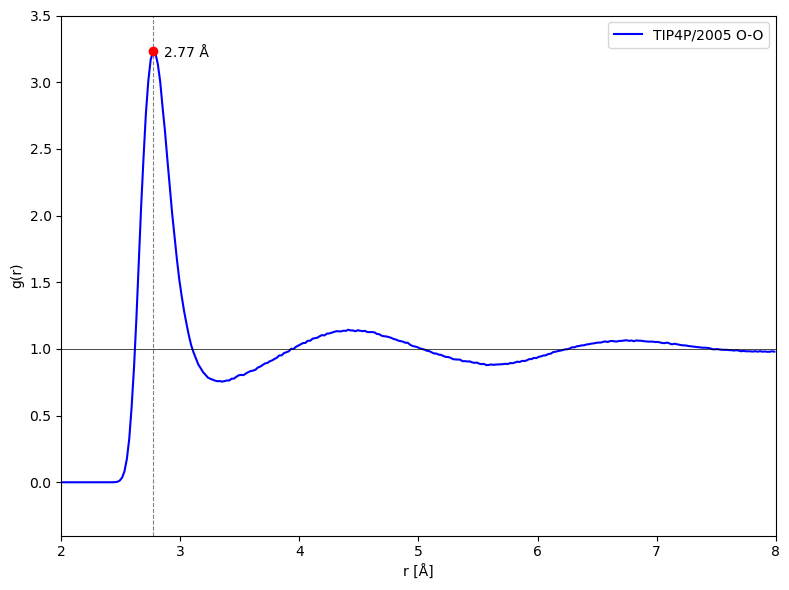

In [ ]:
import matplotlib.pyplot as plt

r_A = r * 10                    # nm -> Å
i_peak = np.argmax(g)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(r_A, g, color="blue", label="TIP4P/2005 O-O")
ax.axvline(r_A[i_peak], color="gray", ls="--", lw=0.8)
ax.plot(r_A[i_peak], g[i_peak], "ro")
ax.annotate(f"{r_A[i_peak]:.2f} Å", (r_A[i_peak], g[i_peak]),
            textcoords="offset points", xytext=(8, -4))
ax.axhline(1, color="k", lw=0.5)   # g(r) = 1 reference
ax.set_xlabel("r [Å]")
ax.set_ylabel("g(r)")
ax.set_ylim(-0.4,3.5)
ax.set_xlim(2, 8)
ax.legend()
fig.tight_layout()
# fig.savefig("/gibbs/arghavan/hp-results-pc/oo_rdf.png", dpi=800)
plt.show()